In [569]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [570]:
df = pd.read_csv("Data/diversified_ecommerce_dataset.csv")
df.head()

,Product ID,Product Name,Category,Price,Discount,Tax Rate,Stock Level,Supplier ID,Customer Age Group,Customer Location,Customer Gender,Shipping Cost,Shipping Method,Return Rate,Seasonality,Popularity Index
0,P6879,Jacket,Apparel,53.85,5,15,150,S535,35-44,"New York, USA",Male,23.32,Standard,4.49,Yes,56
1,P5132,Camera,Electronics,761.26,10,15,224,S583,25-34,"London, UK",Female,20.88,Overnight,16.11,No,79
2,P2941,Sneakers,Footwear,1756.76,5,8,468,S118,25-34,"Tokyo, Japan",Non-Binary,16.43,Standard,4.93,No,40
3,P8545,Cookbooks,Books,295.24,10,15,25,S104,18-24,"Paris, France",Female,27.49,Standard,1.31,No,93
4,P4594,Camera,Electronics,832.00,10,12,340,S331,55+,"Tokyo, Japan",Male,45.93,Overnight,4.37,No,56


In [571]:
print(df.columns)

Index(['Product ID', 'Product Name', 'Category', 'Price', 'Discount',
       'Tax Rate', 'Stock Level', 'Supplier ID', 'Customer Age Group',
       'Customer Location', 'Customer Gender', 'Shipping Cost',
       'Shipping Method', 'Return Rate', 'Seasonality', 'Popularity Index'],
      dtype='object')


In [572]:
print("Shape:", df.shape)

df.info()

df.dtypes

df.isnull().sum()

(df.isnull().mean()*100).sort_values(ascending=False)

df.duplicated().sum()

Shape: (1000000, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 16 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Product ID          1000000 non-null  object 
 1   Product Name        1000000 non-null  object 
 2   Category            1000000 non-null  object 
 3   Price               1000000 non-null  float64
 4   Discount            1000000 non-null  int64  
 5   Tax Rate            1000000 non-null  int64  
 6   Stock Level         1000000 non-null  int64  
 7   Supplier ID         1000000 non-null  object 
 8   Customer Age Group  1000000 non-null  object 
 9   Customer Location   1000000 non-null  object 
 10  Customer Gender     1000000 non-null  object 
 11  Shipping Cost       1000000 non-null  float64
 12  Shipping Method     1000000 non-null  object 
 13  Return Rate         1000000 non-null  float64
 14  Seasonality         1000000 non-null  object 


0

In [573]:
df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1000000, 16)


#  Feature Enginnering 

In [574]:
df['Net Price'] = df['Price'] * (1 - df['Discount']/100)

df['Estimated Revenue'] = (
    df['Net Price']
    + df['Shipping Cost']
)

df['Estimated Profit'] = (
    df['Net Price']
    - df['Shipping Cost']
)

In [575]:

df.isnull().sum()

df.drop_duplicates(inplace=True)

print(df.shape)

(1000000, 19)


In [576]:
category_price = df.groupby('Category')['Price'].mean().sort_values(ascending=False)
print(category_price)

Category
Electronics        1006.564544
Books              1006.561486
Home Appliances    1004.841389
Apparel            1004.347428
Footwear           1003.279185
Name: Price, dtype: float64


In [577]:
df.groupby('Category')['Popularity Index'].mean().sort_values(ascending=False)

Category
Electronics        50.061309
Home Appliances    49.996164
Apparel            49.962248
Footwear           49.955580
Books              49.876016
Name: Popularity Index, dtype: float64

In [578]:
df.groupby('Category')['Return Rate'].mean().sort_values(ascending=False)

Category
Footwear           10.509864
Home Appliances    10.502054
Electronics        10.487290
Books              10.483306
Apparel            10.481973
Name: Return Rate, dtype: float64

In [579]:
df.groupby('Shipping Method')['Shipping Cost'].mean()

Shipping Method
Express      25.000939
Overnight    24.993823
Standard     24.960923
Name: Shipping Cost, dtype: float64

In [580]:
df['Customer Gender'].value_counts()

Male          333791
Non-Binary    333541
Female        332668
Name: Customer Gender, dtype: int64

In [581]:
df.groupby('Customer Location')['Popularity Index'].mean().sort_values(ascending=False)

Customer Location
Dubai, UAE                 50.140529
New York, USA              50.075937
Cape Town, South Africa    50.064331
Paris, France              50.013907
Sydney, Australia          49.999050
Houston, USA               49.985369
Berlin, Germany            49.970402
Toronto, Canada            49.967803
Singapore                  49.952202
Mumbai, India              49.935991
London, UK                 49.921457
Los Angeles, USA           49.912235
Phoenix, USA               49.905141
Chicago, USA               49.863349
Tokyo, Japan               49.844261
Name: Popularity Index, dtype: float64

In [582]:
df[['Discount', 'Popularity Index']].corr()

,Discount,Popularity Index
Discount,1.00000,0.00125
Popularity Index,0.00125,1.00000


In [583]:

print(df.shape)
df.info()
df.head()

(1000000, 19)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 1000000 entries, 0 to 999999
Data columns (total 19 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Product ID          1000000 non-null  object 
 1   Product Name        1000000 non-null  object 
 2   Category            1000000 non-null  object 
 3   Price               1000000 non-null  float64
 4   Discount            1000000 non-null  int64  
 5   Tax Rate            1000000 non-null  int64  
 6   Stock Level         1000000 non-null  int64  
 7   Supplier ID         1000000 non-null  object 
 8   Customer Age Group  1000000 non-null  object 
 9   Customer Location   1000000 non-null  object 
 10  Customer Gender     1000000 non-null  object 
 11  Shipping Cost       1000000 non-null  float64
 12  Shipping Method     1000000 non-null  object 
 13  Return Rate         1000000 non-null  float64
 14  Seasonality         1000000 non-null  object 
 15  Po

,Product ID,Product Name,Category,Price,Discount,Tax Rate,Stock Level,Supplier ID,Customer Age Group,Customer Location,Customer Gender,Shipping Cost,Shipping Method,Return Rate,Seasonality,Popularity Index,Net Price,Estimated Revenue,Estimated Profit
0,P6879,Jacket,Apparel,53.85,5,15,150,S535,35-44,"New York, USA",Male,23.32,Standard,4.49,Yes,56,51.1575,74.4775,27.8375
1,P5132,Camera,Electronics,761.26,10,15,224,S583,25-34,"London, UK",Female,20.88,Overnight,16.11,No,79,685.1340,706.0140,664.2540
2,P2941,Sneakers,Footwear,1756.76,5,8,468,S118,25-34,"Tokyo, Japan",Non-Binary,16.43,Standard,4.93,No,40,1668.9220,1685.3520,1652.4920
3,P8545,Cookbooks,Books,295.24,10,15,25,S104,18-24,"Paris, France",Female,27.49,Standard,1.31,No,93,265.7160,293.2060,238.2260
4,P4594,Camera,Electronics,832.00,10,12,340,S331,55+,"Tokyo, Japan",Male,45.93,Overnight,4.37,No,56,748.8000,794.7300,702.8700


In [584]:
df.isnull().sum()

Product ID            0
Product Name          0
Category              0
Price                 0
Discount              0
Tax Rate              0
Stock Level           0
Supplier ID           0
Customer Age Group    0
Customer Location     0
Customer Gender       0
Shipping Cost         0
Shipping Method       0
Return Rate           0
Seasonality           0
Popularity Index      0
Net Price             0
Estimated Revenue     0
Estimated Profit      0
dtype: int64

In [585]:
df.duplicated().sum()

0

In [586]:
df.describe()

,Price,Discount,Tax Rate,Stock Level,Shipping Cost,Return Rate,Popularity Index,Net Price,Estimated Revenue,Estimated Profit
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,1005.120742,12.516955,10.002052,250.028536,24.985224,10.492896,49.970211,879.303509,904.288733,854.318285
std,574.451223,8.539929,3.406026,144.676275,14.431730,5.484849,29.164875,512.187545,512.361019,512.420627
min,10.000000,0.000000,5.000000,0.000000,0.000000,1.000000,0.000000,7.500000,8.410000,-41.290000
25%,507.860000,5.000000,8.000000,125.000000,12.490000,5.740000,25.000000,439.935625,464.920000,414.839500
50%,1005.430000,15.000000,10.000000,250.000000,24.970000,10.480000,50.000000,871.101750,895.741500,846.208250
75%,1502.310000,20.000000,12.000000,375.000000,37.470000,15.250000,75.000000,1301.885625,1327.022250,1277.010500
max,2000.000000,25.000000,15.000000,500.000000,50.000000,20.000000,100.000000,1999.980000,2048.430000,1999.330000


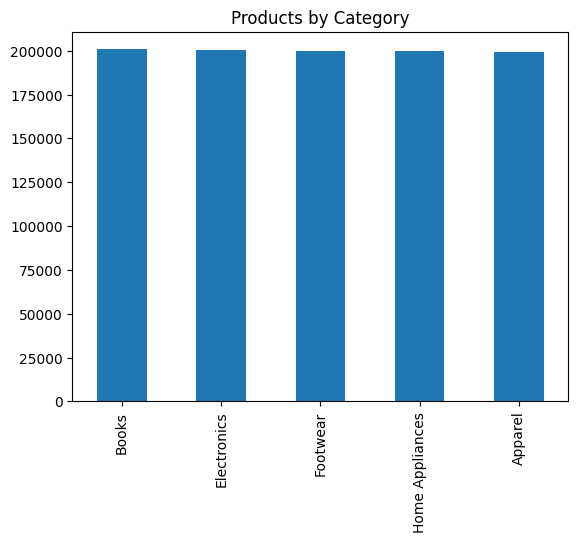

In [587]:
import matplotlib.pyplot as plt

df['Category'].value_counts().plot(kind='bar')
plt.title('Products by Category')
plt.show()

In [588]:
df['Price'].describe()  

count    1000000.000000
mean        1005.120742
std          574.451223
min           10.000000
25%          507.860000
50%         1005.430000
75%         1502.310000
max         2000.000000
Name: Price, dtype: float64

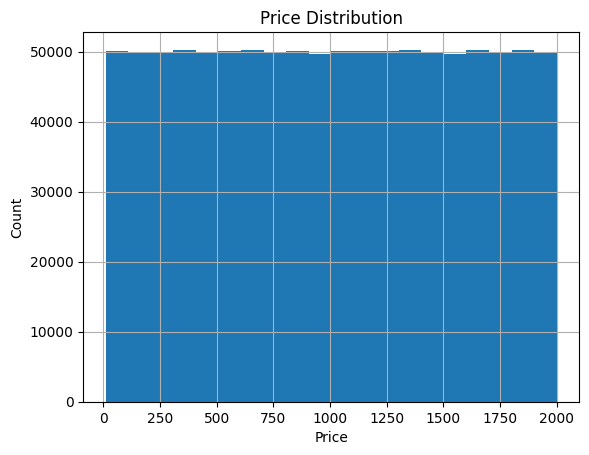

In [589]:
df['Price'].hist(bins=20)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

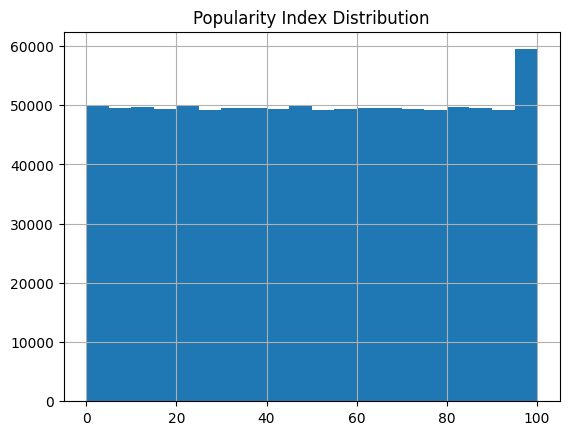

In [590]:
df['Popularity Index'].hist(bins=20)
plt.title('Popularity Index Distribution')
plt.show()

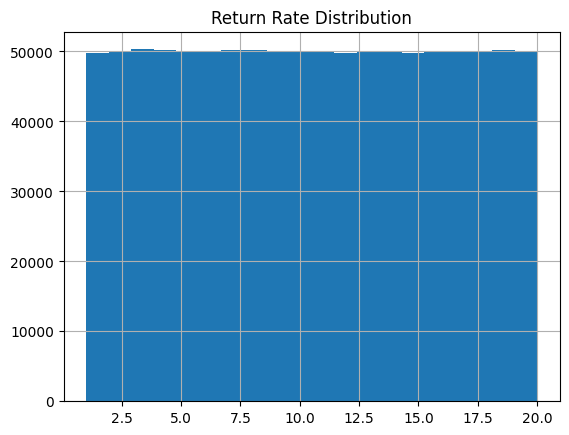

In [591]:
df['Return Rate'].hist(bins=20)
plt.title('Return Rate Distribution')
plt.show()

In [592]:
numeric_cols = ['Price', 'Discount', 'Tax Rate',
                'Stock Level', 'Shipping Cost',
                'Return Rate', 'Popularity Index']

df[numeric_cols].corr()

,Price,Discount,Tax Rate,Stock Level,Shipping Cost,Return Rate,Popularity Index
Price,1.000000,0.000137,-0.000357,0.000213,-0.001758,-0.000405,-0.000233
Discount,0.000137,1.000000,0.001209,0.000425,0.001071,0.000381,0.001250
Tax Rate,-0.000357,0.001209,1.000000,0.001220,-0.000610,-0.001154,0.000660
Stock Level,0.000213,0.000425,0.001220,1.000000,-0.000811,-0.000190,0.000303
Shipping Cost,-0.001758,0.001071,-0.000610,-0.000811,1.000000,-0.000090,0.000519
Return Rate,-0.000405,0.000381,-0.001154,-0.000190,-0.000090,1.000000,0.001648
Popularity Index,-0.000233,0.001250,0.000660,0.000303,0.000519,0.001648,1.000000


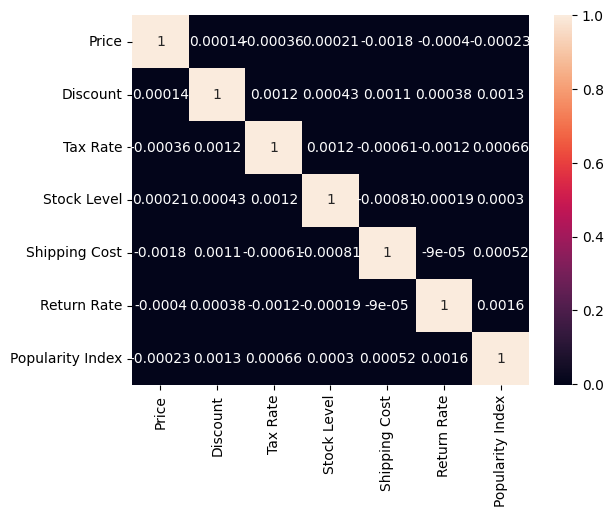

In [593]:
import seaborn as sns

sns.heatmap(df[numeric_cols].corr(), annot=True)
plt.show()

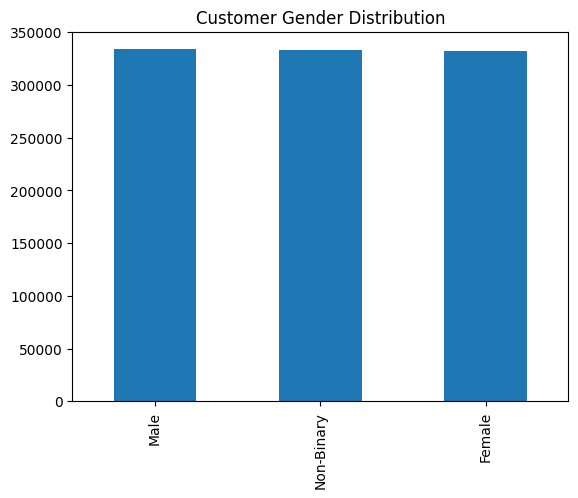

In [594]:
df['Customer Gender'].value_counts().plot(kind='bar')
plt.title('Customer Gender Distribution')
plt.show()  

In [595]:
category_metrics = df.groupby('Category').agg({
    'Price':'mean',
    'Net Price':'mean',
    'Return Rate':'mean',
    'Popularity Index':'mean',
    'Estimated Revenue':'mean'
})

category_metrics.sort_values(
    'Estimated Revenue',
    ascending=False
)

,Price,Net Price,Return Rate,Popularity Index,Estimated Revenue
Category,,,,,
Electronics,1006.564544,880.882419,10.487290,50.061309,905.905021
Books,1006.561486,880.406398,10.483306,49.876016,905.365932
Apparel,1004.347428,878.931705,10.481973,49.962248,903.947032
Home Appliances,1004.841389,878.719251,10.502054,49.996164,903.721907
Footwear,1003.279185,877.570277,10.509864,49.955580,902.496498


In [596]:
df.groupby(
    'Customer Age Group'
)['Popularity Index'].mean().sort_values(ascending=False)

Customer Age Group
35-44    50.013980
45-54    50.006522
55+      49.976913
25-34    49.969847
18-24    49.883960
Name: Popularity Index, dtype: float64

In [597]:
df.groupby(
    'Customer Gender'
)['Popularity Index'].mean()

Customer Gender
Female        49.918540
Male          49.958887
Non-Binary    50.033078
Name: Popularity Index, dtype: float64

In [598]:
df.groupby('Seasonality').agg({
    'Price':'mean',
    'Popularity Index':'mean',
    'Return Rate':'mean'
})

,Price,Popularity Index,Return Rate
Seasonality,,,
No,1005.279320,49.968993,10.503690
Yes,1004.962035,49.971430,10.482094


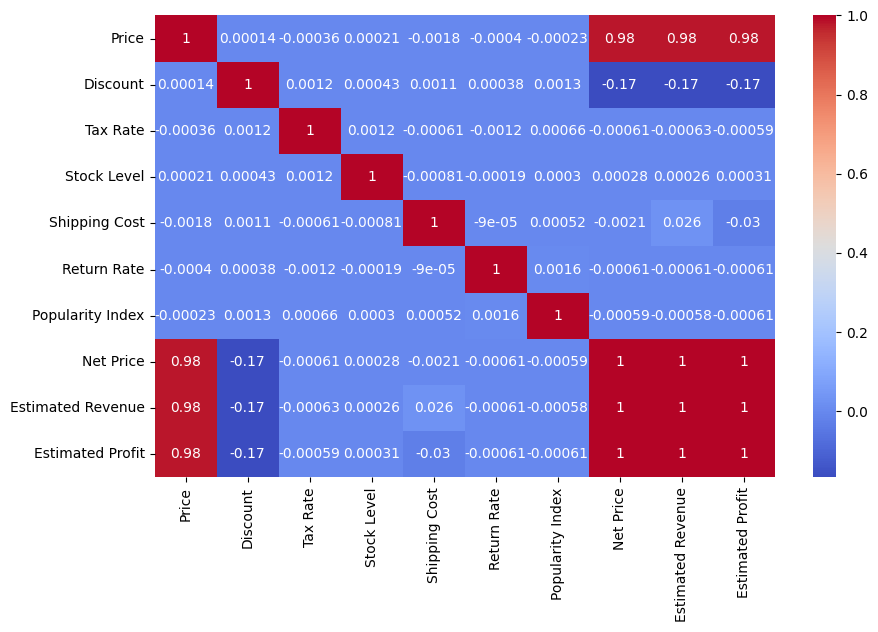

In [599]:
numeric_cols = [
    'Price',
    'Discount',
    'Tax Rate',
    'Stock Level',
    'Shipping Cost',
    'Return Rate',
    'Popularity Index',
    'Net Price',
    'Estimated Revenue',
    'Estimated Profit'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.show()